<a href="https://colab.research.google.com/github/AarsheyaPandey/Aarsheya/blob/main/MLE1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   encounter_id  patient_nbr             race  gender      age weight  \
0       2278392      8222157        Caucasian  Female   [0-10)      ?   
1        149190     55629189        Caucasian  Female  [10-20)      ?   
2         64410     86047875  AfricanAmerican  Female  [20-30)      ?   
3        500364     82442376        Caucasian    Male  [30-40)      ?   
4         16680     42519267        Caucasian    Male  [40-50)      ?   

   admission_type_id  discharge_disposition_id  admission_source_id  \
0                  6                        25                    1   
1                  1                         1                    7   
2                  1                         1                    7   
3                  1                         1                    7   
4                  1                         1                    7   

   time_in_hospital  ... citoglipton insulin  glyburide-metformin  \
0                 1  ...          No      No                   No

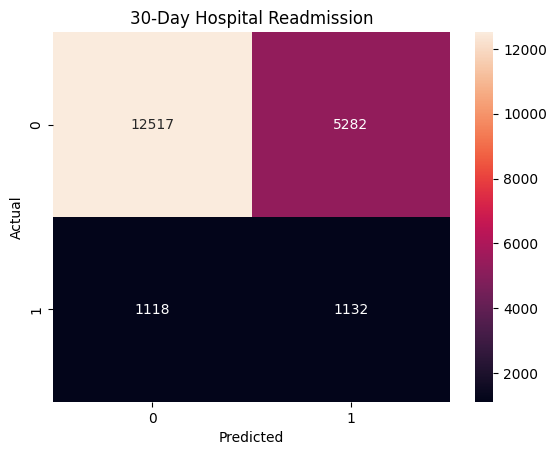

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

df = pd.read_csv("diabetic_data.csv.zip")

print(df.head())
print(df.shape)

df = df.replace("?", np.nan)

df["readmitted_30_days"] = np.where(
	df["readmitted"] == "<30", 1, 0
)

df = df[[
	"diag_1",
	"diag_2",
	"diag_3",
	"num_lab_procedures",
	"number_outpatient",
	"number_emergency",
	"number_inpatient",
	"readmitted_30_days"
]]

df = df.dropna()

for col in ["diag_1", "diag_2", "diag_3"]:
	top = df[col].value_counts().head(10).index
	df[col] = df[col].where(df[col].isin(top), "Other")

df = pd.get_dummies(
	df,
	columns=["diag_1", "diag_2", "diag_3"],
	drop_first=True
)

X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

X_train, X_test, y_train, y_test = train_test_split(
	X,
	y,
	test_size=0.2,
	random_state=42,
	stratify=y
)

# Warning resolved by removing penalty="l2"
model = LogisticRegression(
	max_iter=1000,
	class_weight="balanced"
)

model.fit(X_train, y_train)

probability = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, probability)

print("\nROC-AUC:", round(auc, 3))

prediction = np.where(probability >= 0.5, 1, 0)

cm = confusion_matrix(y_test, prediction)

print("\nConfusion Matrix:")
print(cm)

sns.heatmap(
	cm,
	annot=True,
	fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("30-Day Hospital Readmission")

plt.show()